# 🫀 Heart Failure Prediction — Exploratory Data Analysis
**Dataset:** fedesoriano — Heart Failure Prediction (Kaggle)  
**Objetivo:** Entender el dataset, identificar patrones clínicos y preparar el terreno para el modelado.  
**Fecha:** 2026

---
## Preguntas clínicas a responder en este notebook
1. ¿Cuál es la distribución de la variable target? ¿Hay desbalance?
2. ¿Qué variables numéricas difieren más entre pacientes con y sin enfermedad cardíaca?
3. ¿Qué variables categóricas tienen mayor relación con el target?
4. ¿Hay valores atípicos clínicamente relevantes?
5. ¿Qué variables están más correlacionadas entre sí?
6. ¿Qué features parecen más prometedoras para el modelo?

---
## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías cargadas correctamente ✅')

Librerías cargadas correctamente ✅


---
## 1. Carga de datos

In [2]:
# Ajusta la ruta si es necesario
df = pd.read_csv('heart.csv')

print(f'Shape: {df.shape}')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head()

Shape: (918, 12)
Filas: 918 | Columnas: 12


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


---
## 2. Inspección inicial

In [3]:
# Tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
# Estadísticas descriptivas
df.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [5]:
# Valores nulos
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Sin valores nulos ✅')

Valores nulos por columna:
Sin valores nulos ✅


In [6]:
# Duplicados
dups = df.duplicated().sum()
print(f'Filas duplicadas: {dups}')
if dups > 0:
    df = df.drop_duplicates()
    print(f'Duplicados eliminados. Nuevo shape: {df.shape}')

Filas duplicadas: 0


---
## 3. Variable target: HeartDisease

**Pregunta clínica #1:** ¿Hay desbalance entre clases?

Distribución del target:
              Conteo  Porcentaje
HeartDisease                    
1                508        55.3
0                410        44.7


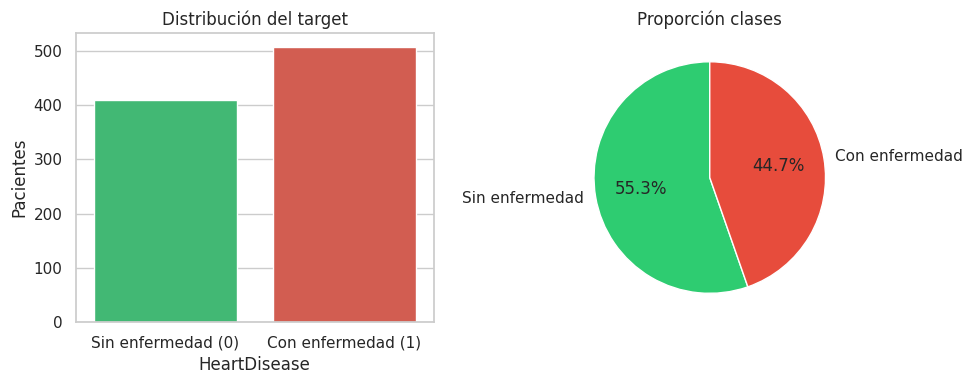


Ratio desbalance: 1.24x
✅ Dataset balanceado — no se requiere técnica especial de balanceo


In [8]:
import os

target_counts = df['HeartDisease'].value_counts()
target_pct = df['HeartDisease'].value_counts(normalize=True) * 100

print('Distribución del target:')
print(pd.DataFrame({'Conteo': target_counts, 'Porcentaje': target_pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barplot
sns.countplot(data=df, x='HeartDisease', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Distribución del target')
axes[0].set_xticklabels(['Sin enfermedad (0)', 'Con enfermedad (1)'])
axes[0].set_ylabel('Pacientes')

# Pie chart
axes[1].pie(target_counts, labels=['Sin enfermedad', 'Con enfermedad'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción clases')

plt.tight_layout()

# Create 'plots' directory if it doesn't exist
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretación
ratio = target_counts.max() / target_counts.min()
print(f'\nRatio desbalance: {ratio:.2f}x')
if ratio < 1.5:
    print('✅ Dataset balanceado — no se requiere técnica especial de balanceo')
elif ratio < 3:
    print('⚠️ Desbalance moderado — considera class_weight="balanced" en los modelos')
else:
    print('🔴 Desbalance importante — usa SMOTE o class_weight="balanced"')

---
## 4. Variables numéricas

**Pregunta clínica #2:** ¿Qué variables difieren entre grupos?

In [9]:
# Identificar columnas numéricas y categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'HeartDisease']

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numéricas ({len(num_cols)}): {num_cols}')
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')

Variables numéricas (6): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Variables categóricas (5): ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


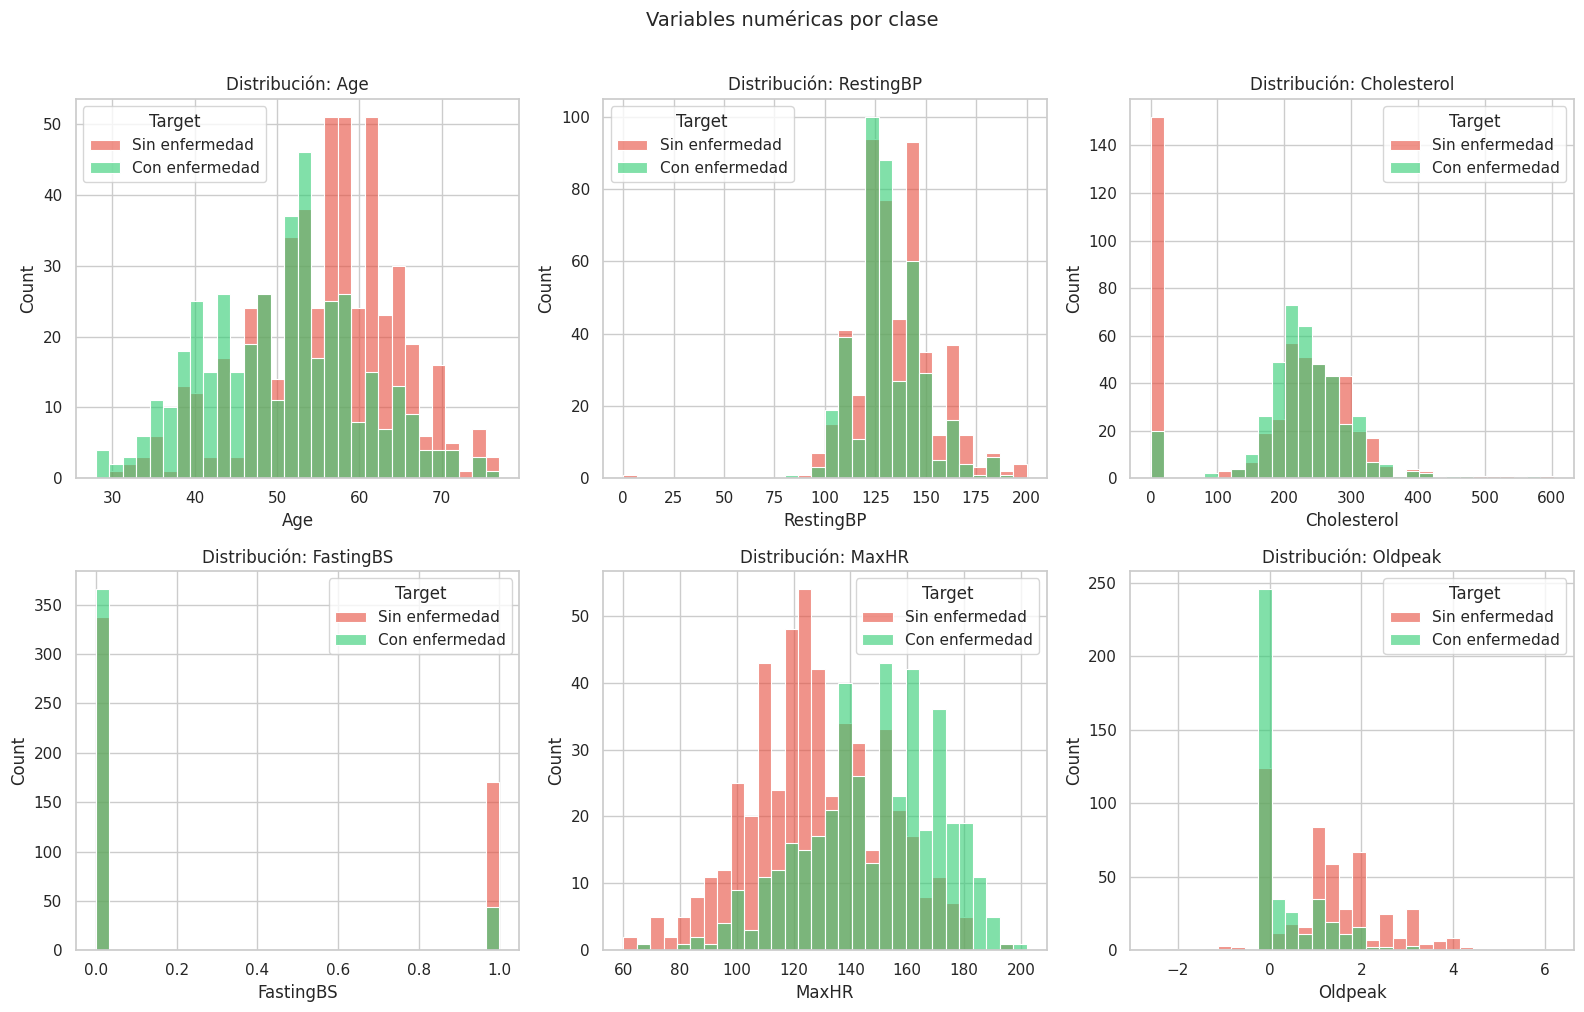

In [10]:
# Distribución de variables numéricas por target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i >= len(axes):
        break
    sns.histplot(data=df, x=col, hue='HeartDisease', bins=30,
                 palette=['#2ecc71', '#e74c3c'], alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Distribución: {col}')
    axes[i].legend(labels=['Sin enfermedad', 'Con enfermedad'], title='Target')

# Ocultar ejes vacíos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables numéricas por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

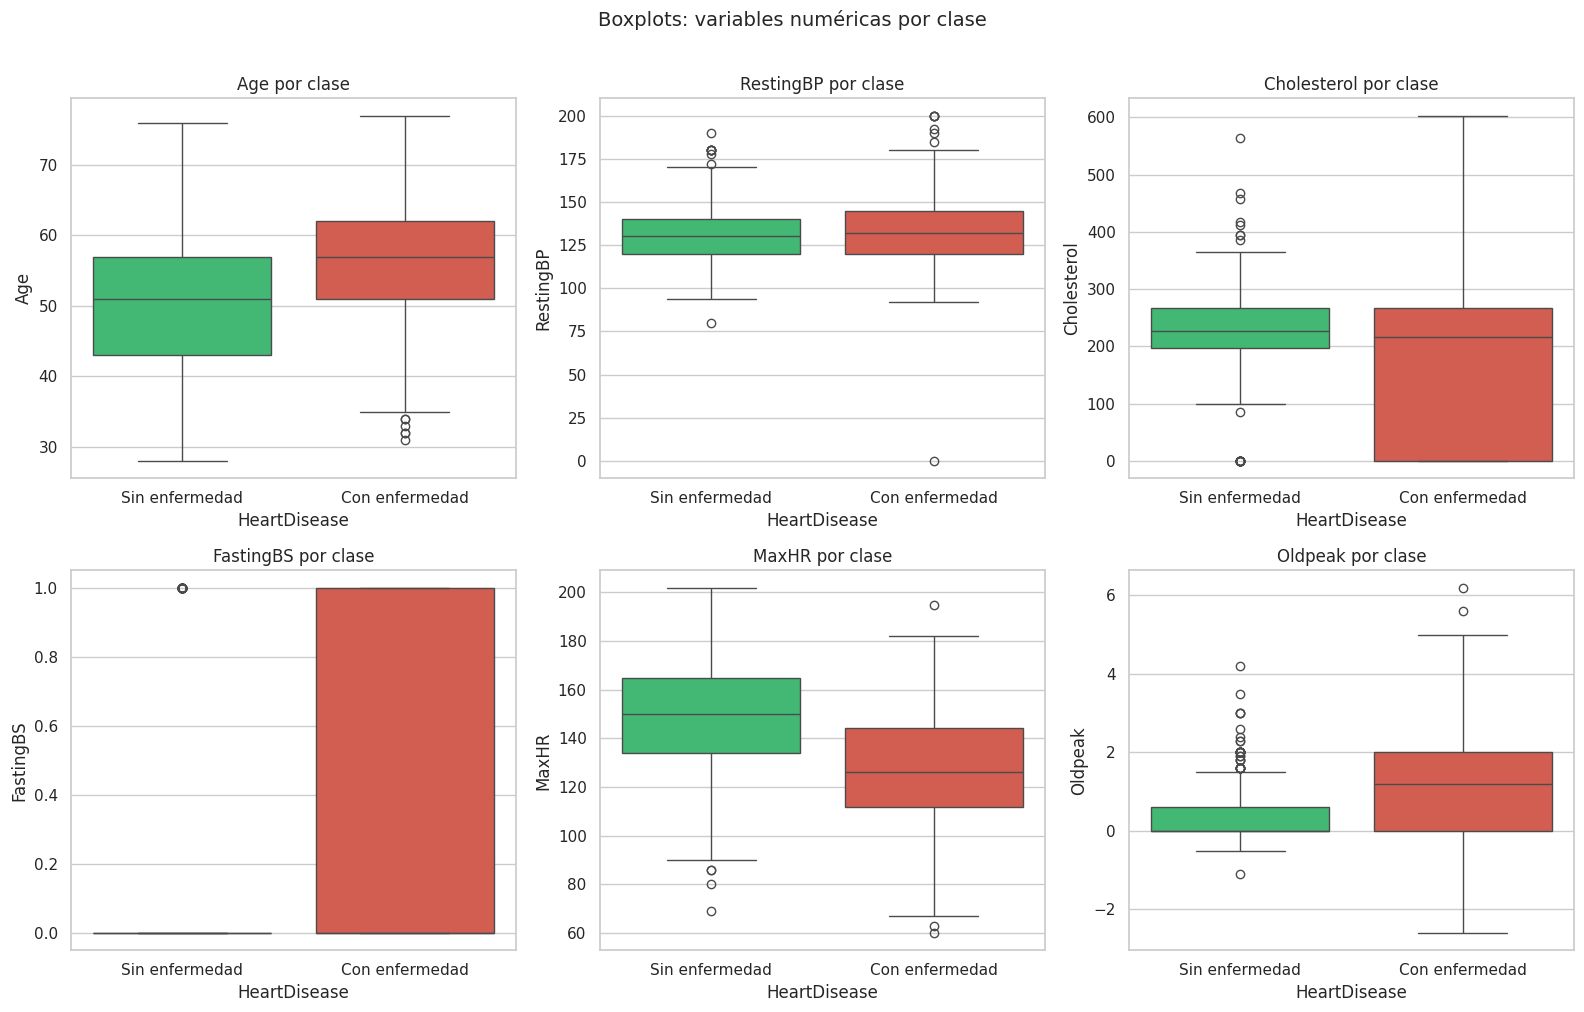

In [11]:
# Boxplots por target — detectar diferencias entre grupos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i >= len(axes):
        break
    sns.boxplot(data=df, x='HeartDisease', y=col,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col} por clase')
    axes[i].set_xticklabels(['Sin enfermedad', 'Con enfermedad'])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots: variables numéricas por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/03_boxplots_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Tabla comparativa de medias por grupo
print('Media de variables numéricas por clase:')
df.groupby('HeartDisease')[num_cols].mean().round(2).T.rename(
    columns={0: 'Sin enfermedad', 1: 'Con enfermedad'}
)

Media de variables numéricas por clase:


HeartDisease,Sin enfermedad,Con enfermedad
Age,50.55,55.90
RestingBP,130.18,134.19
Cholesterol,227.12,175.94
FastingBS,0.11,0.33
MaxHR,148.15,127.66
Oldpeak,0.41,1.27


---
## 5. Variables categóricas

**Pregunta clínica #3:** ¿Qué categorías están asociadas a mayor riesgo?

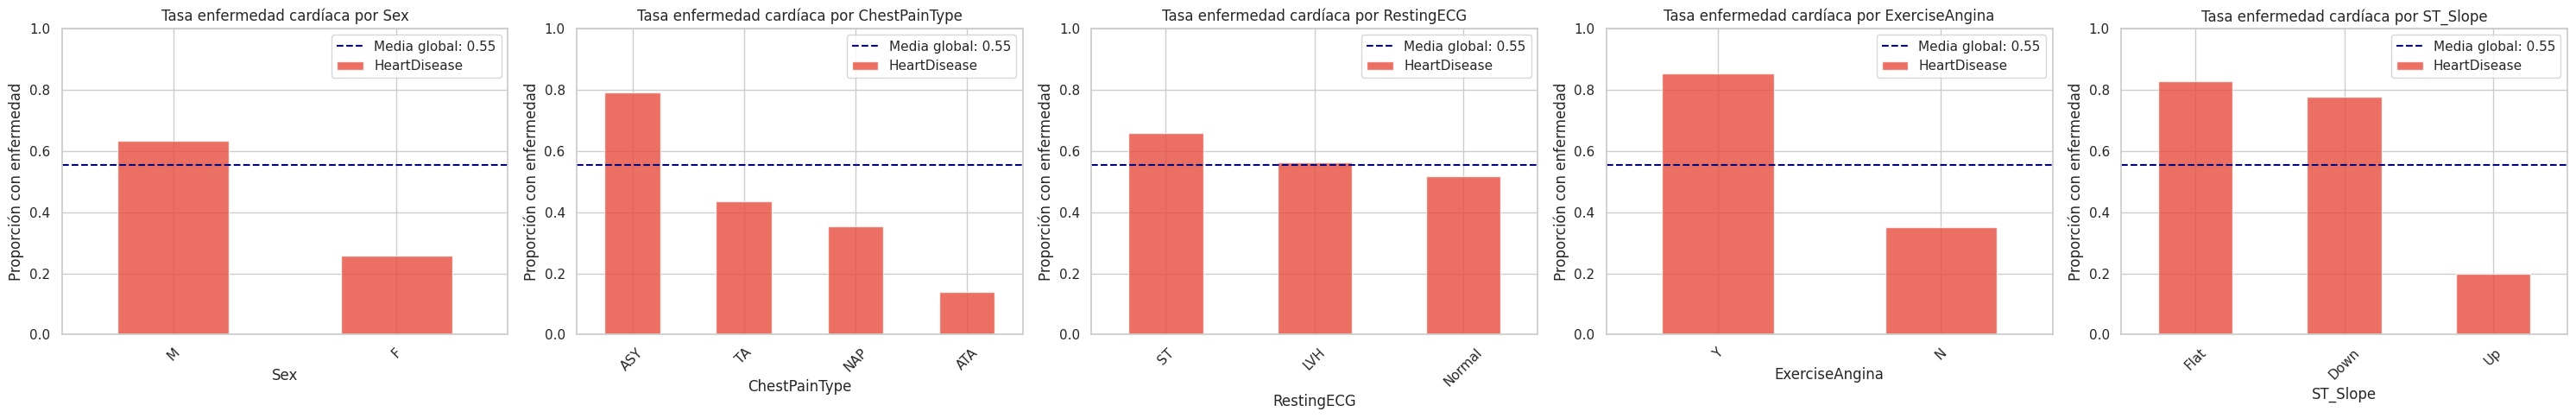

In [13]:
# Tasa de enfermedad cardíaca por variable categórica
n_cats = len(cat_cols)
if n_cats == 0:
    print('No hay columnas categóricas detectadas como object.')
    print('Nota: ST_Slope, ChestPainType, RestingECG, Sex pueden ser object según la versión del CSV.')
else:
    fig, axes = plt.subplots(1, n_cats, figsize=(6 * n_cats, 5))
    if n_cats == 1:
        axes = [axes]

    for i, col in enumerate(cat_cols):
        rate = df.groupby(col)['HeartDisease'].mean().sort_values(ascending=False)
        rate.plot(kind='bar', ax=axes[i], color='#e74c3c', alpha=0.8, edgecolor='white')
        axes[i].set_title(f'Tasa enfermedad cardíaca por {col}')
        axes[i].set_ylabel('Proporción con enfermedad')
        axes[i].set_ylim(0, 1)
        axes[i].axhline(df['HeartDisease'].mean(), color='navy', linestyle='--',
                        label=f'Media global: {df["HeartDisease"].mean():.2f}')
        axes[i].legend()
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('plots/04_categorical_risk_rates.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Outliers

**Pregunta clínica #4:** ¿Hay valores atípicos clínicamente posibles o errores de registro?

In [14]:
# Detectar outliers con IQR
print('Análisis de outliers (método IQR):\n')
outlier_report = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100
    outlier_report.append({
        'Variable': col,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Lower fence': round(lower, 2),
        'Upper fence': round(upper, 2),
        'N outliers': n_out,
        '% outliers': round(pct_out, 1)
    })

outlier_df = pd.DataFrame(outlier_report).set_index('Variable')
display(outlier_df)

# NOTA CLÍNICA IMPORTANTE:
# Cholesterol = 0 es un error de registro (no fisiológico).
# RestingBP = 0 también es imposible.
# Estos deben tratarse como NaN antes de modelar.
print('\n⚠️  NOTA: Cholesterol=0 y RestingBP=0 son valores imposibles fisiológicamente.')
print(f'Pacientes con Cholesterol=0: {(df["Cholesterol"] == 0).sum()}')
print(f'Pacientes con RestingBP=0: {(df["RestingBP"] == 0).sum()}')

Análisis de outliers (método IQR):



,Min,Max,Lower fence,Upper fence,N outliers,% outliers
Variable,,,,,,
Age,28.0,77.0,27.50,79.50,0,0.0
RestingBP,0.0,200.0,90.00,170.00,28,3.1
Cholesterol,0.0,603.0,32.62,407.62,183,19.9
FastingBS,0.0,1.0,0.00,0.00,214,23.3
MaxHR,60.0,202.0,66.00,210.00,2,0.2
Oldpeak,-2.6,6.2,-2.25,3.75,16,1.7



⚠️  NOTA: Cholesterol=0 y RestingBP=0 son valores imposibles fisiológicamente.
Pacientes con Cholesterol=0: 172
Pacientes con RestingBP=0: 1


---
## 7. Matriz de correlación

**Pregunta clínica #5:** ¿Qué variables correlacionan entre sí? ¿Y con el target?

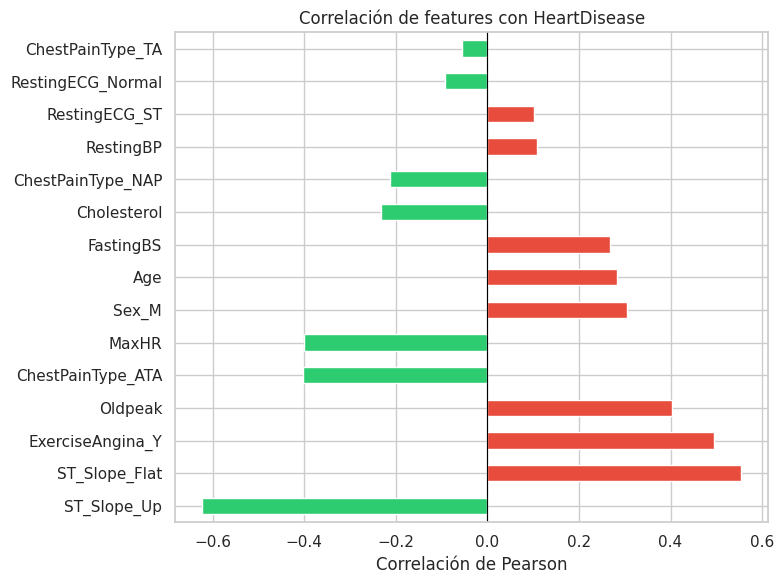

Top 5 features más correlacionadas con el target:
ST_Slope_Up         -0.622164
ST_Slope_Flat        0.554134
ExerciseAngina_Y     0.494282
Oldpeak              0.403951
ChestPainType_ATA   -0.401924


In [15]:
# Codificar variables categóricas para la correlación
df_encoded = pd.get_dummies(df, drop_first=True)

# Correlación con el target
corr_target = df_encoded.corr()['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target]
corr_target.plot(kind='barh', color=colors)
plt.title('Correlación de features con HeartDisease')
plt.xlabel('Correlación de Pearson')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('plots/05_correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features más correlacionadas con el target:')
print(corr_target.head(5).to_string())

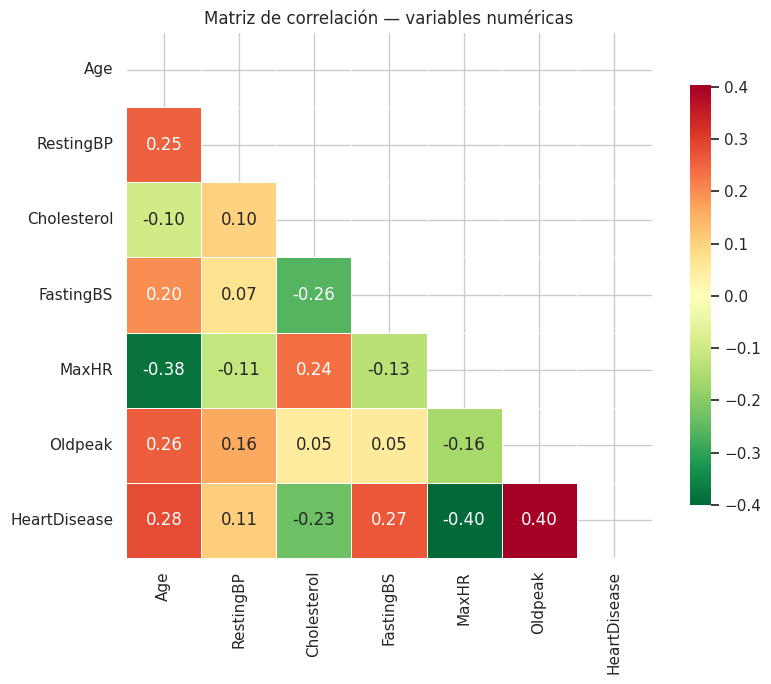

In [16]:
# Heatmap de correlación entre variables numéricas
num_corr = df[num_cols + ['HeartDisease']].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(num_corr, dtype=bool))
sns.heatmap(num_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.savefig('plots/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Análisis bivariado clave

**Pregunta clínica #6:** Visualizaciones que revelan patrones clínicos reales.

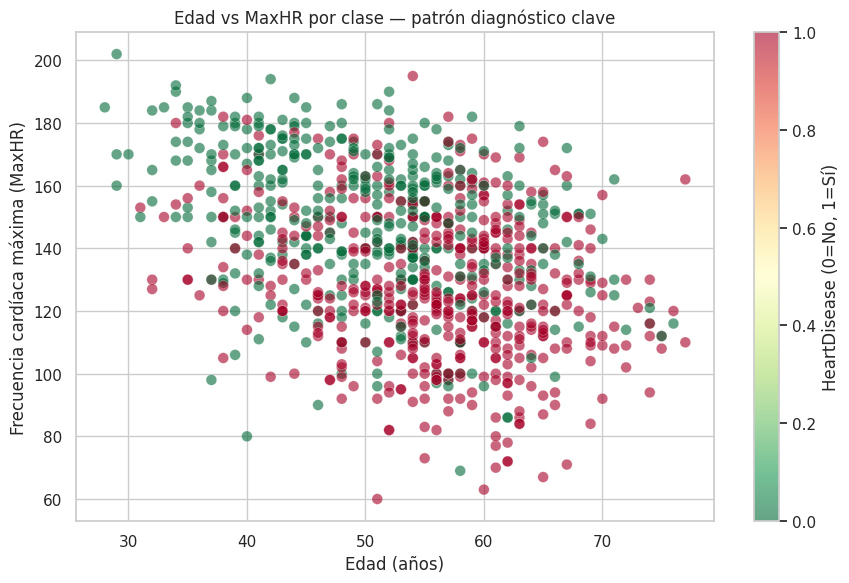

Observación: a mayor edad y menor MaxHR → mayor riesgo de cardiopatía.


In [17]:
# Edad vs MaxHR coloreado por target — patrón clásico de cardiopatía
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df['Age'], df['MaxHR'],
    c=df['HeartDisease'], cmap='RdYlGn_r',
    alpha=0.6, edgecolors='white', linewidths=0.3, s=60
)
plt.colorbar(scatter, label='HeartDisease (0=No, 1=Sí)')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia cardíaca máxima (MaxHR)')
plt.title('Edad vs MaxHR por clase — patrón diagnóstico clave')
plt.tight_layout()
plt.savefig('plots/07_age_vs_maxhr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observación: a mayor edad y menor MaxHR → mayor riesgo de cardiopatía.')

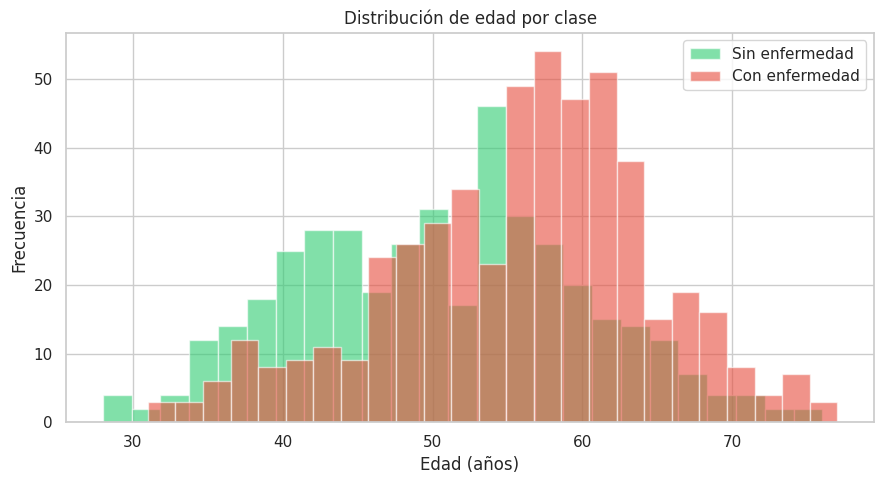

In [18]:
# Distribución de edad por target
plt.figure(figsize=(9, 5))
df[df['HeartDisease']==0]['Age'].hist(bins=25, alpha=0.6, color='#2ecc71', label='Sin enfermedad')
df[df['HeartDisease']==1]['Age'].hist(bins=25, alpha=0.6, color='#e74c3c', label='Con enfermedad')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.title('Distribución de edad por clase')
plt.legend()
plt.tight_layout()
plt.savefig('plots/08_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Resumen clínico y conclusiones

> Completa esta sección con tus observaciones después de ejecutar el notebook.

In [19]:
print('=' * 55)
print('RESUMEN DEL DATASET')
print('=' * 55)
print(f'Total pacientes:        {len(df)}')
print(f'Features:               {df.shape[1] - 1}')
print(f'Valores nulos:          {df.isnull().sum().sum()}')
print(f'Duplicados eliminados:  {dups}')
print(f'% con enfermedad:       {df["HeartDisease"].mean()*100:.1f}%')
print(f'Cholesterol=0 (erro):   {(df["Cholesterol"]==0).sum()} filas')
print(f'RestingBP=0 (error):    {(df["RestingBP"]==0).sum()} filas')
print('=' * 55)
print('\nTop features por correlación con target:')
print(corr_target.head(5).to_string())

RESUMEN DEL DATASET
Total pacientes:        918
Features:               11
Valores nulos:          0
Duplicados eliminados:  0
% con enfermedad:       55.3%
Cholesterol=0 (erro):   172 filas
RestingBP=0 (error):    1 filas

Top features por correlación con target:
ST_Slope_Up         -0.622164
ST_Slope_Flat        0.554134
ExerciseAngina_Y     0.494282
Oldpeak              0.403951
ChestPainType_ATA   -0.401924


---
## ✍️ Conclusiones (rellenar manualmente)

**1. Distribución del target:**  
_La distribución de la variable objetivo es **equilibrada (55.3% positivo vs 44.7% negativo)**. Esto implica que las métricas de evaluación estándar como el **Accuracy** (Exactitud) serán fiables y no se requieren técnicas de remuestreo (SMOTE) o ajuste de pesos en el modelo._

**2. Variables más informativas:**  
_Las variables con mayor poder predictivo son de naturaleza **electrocardiográfica** y **sintomática**. Destacan la **pendiente del segmento ST (ST_Slope)** y la presencia de **angina por ejercicio**. Es notable que ST_Slope_Up presenta una fuerte correlación negativa, sugiriendo que es un factor protector o indicador de normalidad, mientras que ST_Slope_Flat y Oldpeak son claros indicadores de patología._

**3. Problemas de calidad detectados:**  
_Se han detectado fallos en la integridad de los datos: **18.7% de la columna Cholesterol** presenta valores de 0, lo cual es fisiológicamente incompatible con la vida. Esto sugiere un error de registro o valores perdidos (NaN) imputados erróneamente como cero. Asimismo, existe un registro con **RestingBP=0**, estos fallos deben ser tratados mediante imputación (media/mediana) o eliminación para no sesgar el modelo._

**4. Hipótesis clínicas:**  
_Los patrones coinciden con la fisiopatología cardiovascular: el riesgo de cardiopatía aumenta cuando el corazón muestra **incapacidad de respuesta en frecuencia** (MaxHR baja) y **anomalías en la recuperación eléctrica** tras el esfuerzo (Oldpeak y ST_Slope flat/down). Estos signos indican que el músculo cardíaco está trabajando bajo hipoxia (falta de oxígeno) cuando se le exige carga mecánica. Además, la importancia del **tipo de dolor torácico** (ChestPainType_ATA como asintomático o dolor atípico) son criterios diagnósticos estándar en la práctica clínica para detectar isquemia miocárdica._

**5. Plan para el siguiente notebook (Preprocesamiento):**  
- [ ] Tratar Cholesterol=0 y RestingBP=0 (imputar con mediana por grupo)
- [ ] Encoding de variables categóricas (OneHot o Label)
- [ ] Escalar variables numéricas (StandardScaler)
- [ ] Train/test split estratificado
- [ ] Guardar dataset procesado como `heart_processed.csv`

---
*Notebook 01 completado — siguiente: `02_preprocessing_modeling.ipynb`*